# **Step 0. Mount Google Drive and Load Dataset**



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

car_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/auto_mpg_binarised.csv')

car_data.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name,mpg_high
0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu,0
1,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320,0
2,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite,0
3,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst,0
4,8,302.0,140.0,3449.0,10.5,70,1,ford torino,0


# **Step 1. Understanding the Count Plot**


# **📊Analyze the Frequency Distribution of a Categorical Feature**

## **🎯 Objective**

Before building a Machine Learning model, it is important to understand how the values of a **categorical feature** are distributed.

In this step, we create a reusable function called `plot_categorical_frequency()` that visualizes the frequency of categories using a Count Plot.

This helps answer questions such as:

- Which category appears most frequently?
- Are some categories rare?
- Is the dataset balanced?
- Do we have enough observations in every category?

Understanding these patterns helps us make informed decisions during feature engineering and model building.

**🤔 Why Do We Use a Count Plot?**

A **Count Plot** is one of the most commonly used visualizations for **categorical** variables.

Unlike a histogram, which is used for numerical data, a Count Plot displays the number of observations in each category.

For example, if we analyze the cylinders column, the Count Plot tells us:

- How many cars have 4 cylinders
- How many cars have 6 cylinders
- How many cars have 8 cylinders

This allows us to quickly identify dominant and underrepresented categories.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_categorical_frequency(data_frame: pd.DataFrame, column_name: str) -> None:
    # 1. Establish visual style for readability
    sns.set_theme(style="whitegrid")

    # 2. Work on a copy to protect the original raw dataset from side-effects
    working_data = data_frame.copy()

    # 3. Translate numeric codes into descriptive human text if analyzing 'origin'
    if column_name == 'origin':
        region_mapping = {1: 'USA', 2: 'Europe', 3: 'Japan'}
        working_data['origin'] = working_data['origin'].map(region_mapping)

    # 4. Initialize the drawing canvas size (Width: 8 inches, Height: 6 inches)
    plt.figure(figsize=(8, 6))

    # 5. Generate the frequency bar chart (Count Plot)
    sns.countplot(
        data=working_data,
        x=column_name,
        color='skyblue',
        edgecolor='black'
    )

    # 6. Apply explicit, clean labels and titles
    clean_title = column_name.replace('_', ' ').title()
    plt.title(f"Frequency Distribution of {clean_title}", fontsize=14, pad=15)
    plt.xlabel(clean_title, fontsize=12)
    plt.ylabel("Total Count (Frequency)", fontsize=12)

    # 7. Optimize margins to prevent text clipping and render the graph
    plt.tight_layout()
    plt.show()

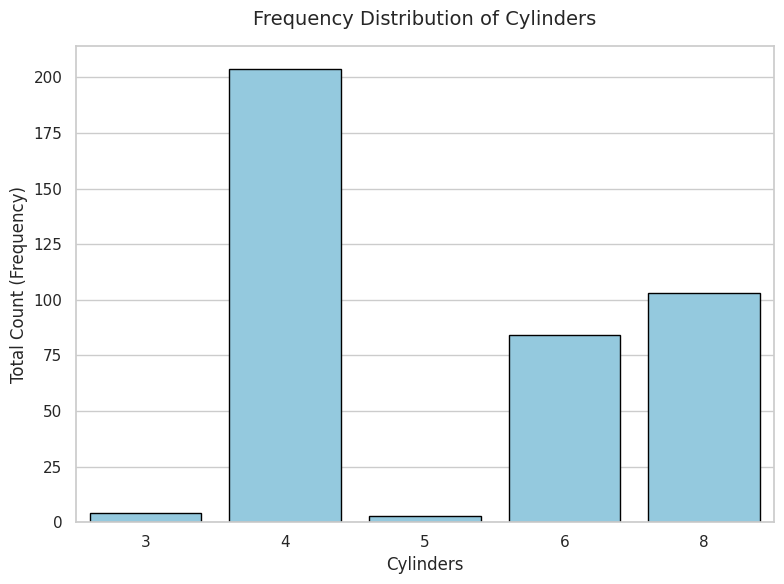

In [ ]:
plot_categorical_frequency(car_data, column_name="cylinders")


This function call tells Python to analyze the `cylinders` column and display its frequency distribution.

You can visualize any **categorical feature** by changing the column name.

For example:

```
plot_categorical_frequency(car_data, "origin")
plot_categorical_frequency(car_data, "model_year")
```



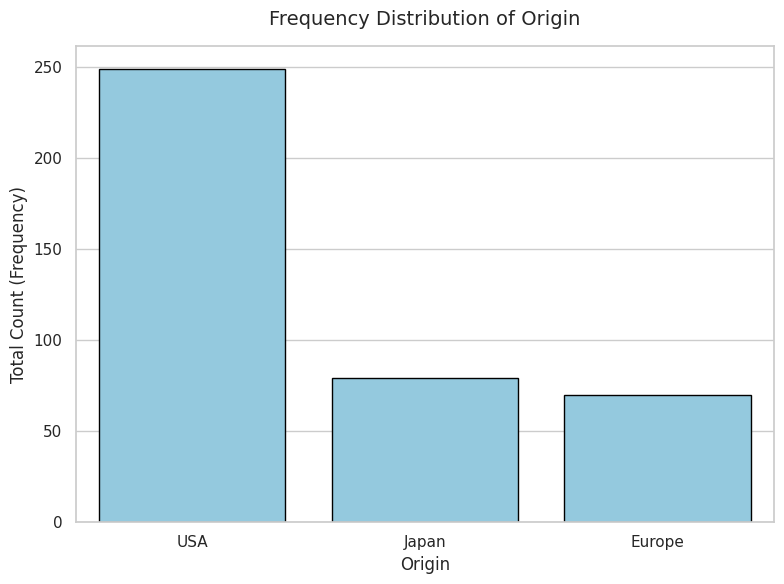

In [ ]:
plot_categorical_frequency(car_data, "origin")

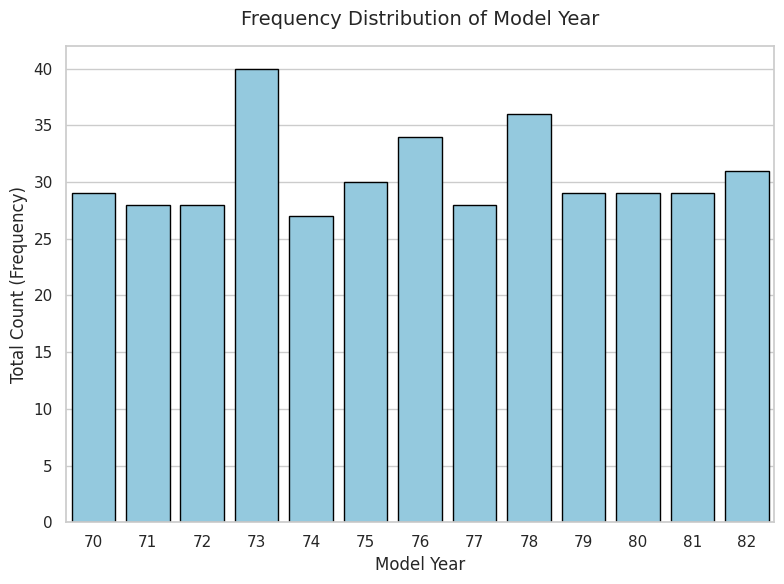

In [ ]:
plot_categorical_frequency(car_data, "model_year")